# Logistic Regression Model

Training a Logistic Regression model for predicting on-time delivery.

In [17]:
# Imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Load feature engineered data
df = pd.read_csv('../data/final_cleaned_data.csv')
print('Data loaded, shape:', df.shape)

# Prepare features and target
X = df.drop(['ID', 'Reached.on.Time_Y.N'], axis=1)
y = df['Reached.on.Time_Y.N']
print('Features shape:', X.shape)
print('Target shape:', y.shape)

Data loaded, shape: (10999, 21)
Features shape: (10999, 19)
Target shape: (10999,)


In [18]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (8799, 19) Test shape: (2200, 19)


In [19]:
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in y_train:", y_train.isnull().sum())

Missing values in X_train: 0
Missing values in y_train: 0


In [20]:
import numpy as np

# Replace inf
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Fill missing
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

In [21]:
# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
print('Model trained successfully')

Model trained successfully


In [22]:
# Predictions
y_pred = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

# Evaluation
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.644090909090909

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.58      0.57       887
           1       0.71      0.69      0.70      1313

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.65      0.64      0.65      2200



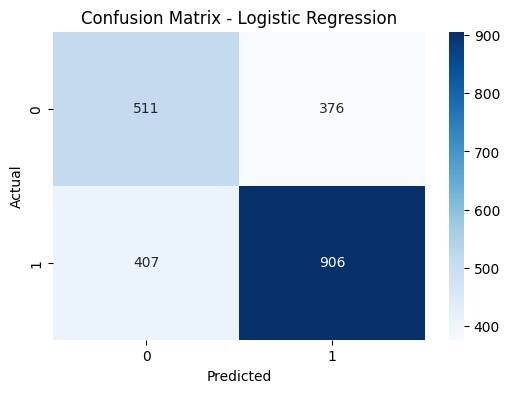

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

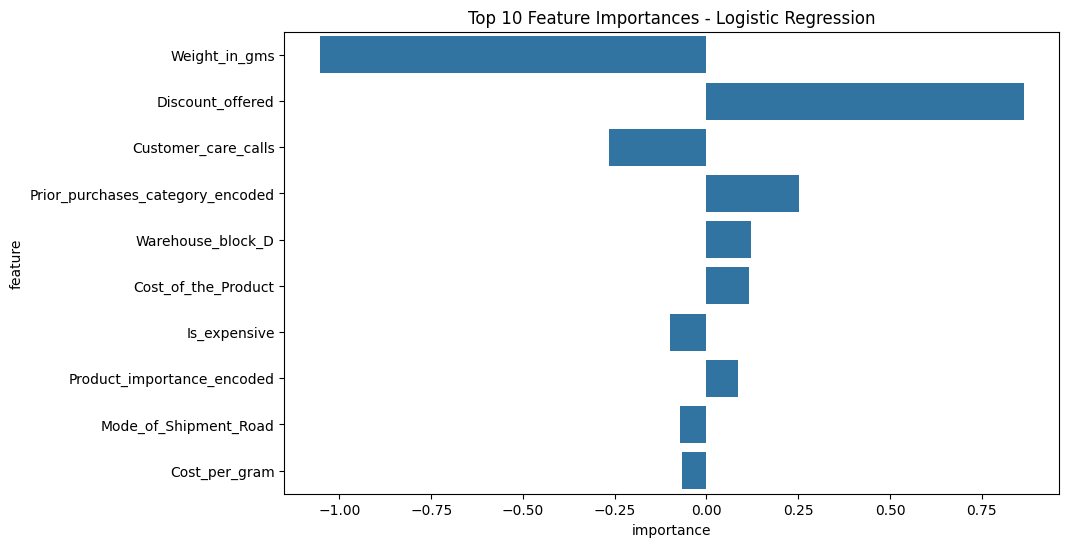

In [24]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': lr_model.coef_[0]
}).sort_values('importance', key=abs, ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title('Top 10 Feature Importances - Logistic Regression')
plt.show()

In [25]:
# Save model
joblib.dump(lr_model, '../models/logistic_regression.pkl')
print('Logistic Regression model saved to ../models/logistic_regression.pkl')

Logistic Regression model saved to ../models/logistic_regression.pkl
